[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxiRuess/DeepLearning_101/blob/main/notebooks/08_JAX/01_JAX_Fundamentals.ipynb)

# JAX Fundamentals — A Different Way to Think About Deep Learning

JAX is Google's numerical computing library. It's **not** a neural network framework — it's a
system for transforming mathematical functions. Neural networks are just one application.

If PyTorch says *"here's a tensor, do operations on it"*, JAX says *"here's a function, let me
transform it"*.

| | PyTorch | JAX |
|---|---|---|
| Mental model | Object-oriented (tensors with methods) | **Functional (transform functions)** |
| Execution | Eager by default | **Trace + compile by default** |
| Autodiff | `.backward()` on loss | **`jax.grad(fn)` returns a new function** |
| Batching | Manual batch dimension everywhere | **`jax.vmap(fn)` auto-batches any function** |
| Side effects | Allowed (in-place ops, global state) | **Forbidden (pure functions only)** |
| GPU/TPU | CUDA | **XLA (works on GPU, TPU, and CPU)** |
| Used by | Meta, most industry | **Google DeepMind, Google Brain** |

## The Four Core Transforms

Everything in JAX is built on four function transformations:

1. **`jax.grad`** — differentiate any function
2. **`jax.jit`** — compile any function for speed
3. **`jax.vmap`** — auto-batch any function
4. **`jax.pmap`** — auto-parallelize across devices

These compose freely: `jax.jit(jax.vmap(jax.grad(fn)))` is valid.

## Setup

In [1]:
import sys, os

# In Colab, clone the repo so local imports (src/) work
if "google.colab" in str(get_ipython()):
    if not os.path.exists("/content/DeepLearning_101"):
        !git clone --depth 1 https://github.com/MaxiRuess/DeepLearning_101.git /content/DeepLearning_101
    os.chdir("/content/DeepLearning_101/notebooks/08_JAX")
    sys.path.insert(0, "/content/DeepLearning_101")
else:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [2]:
try:
    import jax
    import jax.numpy as jnp
except ImportError:
    %pip install -q jax jaxlib
    import jax
    import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.9.2
Devices: [CpuDevice(id=0)]


## 1. JAX Arrays — NumPy but Accelerated

JAX's `jax.numpy` is a near drop-in replacement for NumPy. The key difference:
JAX arrays are **immutable** — you can't modify them in place.

```python
# NumPy: mutable
x = np.zeros(3)
x[0] = 1.0        # OK

# JAX: immutable
x = jnp.zeros(3)
x[0] = 1.0        # ERROR!
x = x.at[0].set(1.0)  # OK — returns a new array
```

Why? Because immutability enables JAX's transformations. If a function modifies
its inputs, `jax.grad` can't safely differentiate it.

In [3]:
# JAX arrays work like NumPy
x = jnp.array([1.0, 2.0, 3.0])
y = jnp.array([4.0, 5.0, 6.0])

print(f"x + y = {x + y}")
print(f"x @ y = {x @ y}")
print(f"jnp.sin(x) = {jnp.sin(x)}")
print(f"Type: {type(x)}")
print(f"Device: {x.devices()}")

x + y = [5. 7. 9.]
x @ y = 32.0
jnp.sin(x) = [0.84147096 0.9092974  0.14112   ]
Type: <class 'jaxlib._jax.ArrayImpl'>
Device: {CpuDevice(id=0)}


In [4]:
# Immutability in action
x = jnp.zeros(3)

# This would fail: x[0] = 1.0
# Instead, use .at[].set() which returns a NEW array
x_new = x.at[0].set(1.0)

print(f"Original: {x}")   # unchanged!
print(f"New:      {x_new}")

Original: [0. 0. 0.]
New:      [1. 0. 0.]


## 2. `jax.grad` — Differentiation as a Function Transform

In PyTorch, you call `.backward()` on a loss tensor. In JAX, `jax.grad` takes a **function**
and returns a **new function** that computes the gradient:

```python
# PyTorch:
loss = model(x)
loss.backward()        # mutates .grad attributes
gradient = param.grad

# JAX:
grad_fn = jax.grad(loss_fn)  # returns a NEW function
gradient = grad_fn(params, x)  # call it like any function
```

This is more composable — you can differentiate the gradient function itself
to get second derivatives: `jax.grad(jax.grad(fn))`.

In [5]:
# Simple example: f(x) = x^2, so f'(x) = 2x
def f(x):
    return x ** 2

# jax.grad returns a NEW function
df = jax.grad(f)

print(f"f(3.0)  = {f(3.0)}")     # 9.0
print(f"f'(3.0) = {df(3.0)}")    # 6.0  (2 * 3)

# Higher-order derivatives — just compose!
ddf = jax.grad(jax.grad(f))       # second derivative
dddf = jax.grad(jax.grad(jax.grad(f)))  # third derivative

print(f"f''(3.0)  = {ddf(3.0)}")  # 2.0
print(f"f'''(3.0) = {dddf(3.0)}") # 0.0

f(3.0)  = 9.0
f'(3.0) = 6.0
f''(3.0)  = 2.0
f'''(3.0) = 0.0


In [6]:
# More interesting: gradient of a loss function
def mse_loss(w, x, y):
    """Mean squared error: (w @ x - y)^2"""
    pred = jnp.dot(w, x)
    return jnp.mean((pred - y) ** 2)

# Random data
key = jax.random.PRNGKey(42)
w = jax.random.normal(key, (3,))
x = jnp.array([1.0, 2.0, 3.0])
y = jnp.array(5.0)

# Compute gradient w.r.t. first argument (w)
grad_fn = jax.grad(mse_loss)  # differentiates w.r.t. arg 0 by default
grads = grad_fn(w, x, y)

print(f"Weights:  {w}")
print(f"Loss:     {mse_loss(w, x, y):.4f}")
print(f"Gradient: {grads}")

Weights:  [-0.02830462  0.46713185  0.29570296]
Loss:     10.2844
Gradient: [ -6.413864 -12.827728 -19.241592]


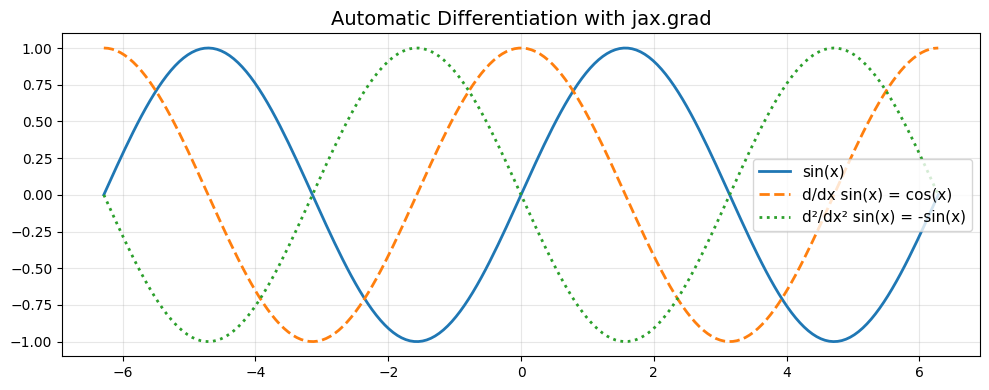

In [7]:
# Visualize: gradient of sin(x)
x_vals = jnp.linspace(-2 * jnp.pi, 2 * jnp.pi, 200)

sin_grad = jax.grad(jnp.sin)   # returns cos
sin_grad2 = jax.grad(jax.grad(jnp.sin))  # returns -sin

# vmap to apply scalar grad to a vector (preview of section 4!)
y_sin = jax.vmap(jnp.sin)(x_vals)
y_cos = jax.vmap(sin_grad)(x_vals)
y_neg_sin = jax.vmap(sin_grad2)(x_vals)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_vals, y_sin, label="sin(x)", linewidth=2)
ax.plot(x_vals, y_cos, "--", label="d/dx sin(x) = cos(x)", linewidth=2)
ax.plot(x_vals, y_neg_sin, ":", label="d²/dx² sin(x) = -sin(x)", linewidth=2)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title("Automatic Differentiation with jax.grad", fontsize=14)
plt.tight_layout()
plt.show()

## 3. `jax.jit` — Compile for Speed

By default, JAX traces your function and compiles it to **XLA** (Accelerated Linear Algebra)
before running it. `jax.jit` makes this explicit:

```python
fast_fn = jax.jit(fn)  # trace + compile on first call
fast_fn(x)             # first call: slow (compiling)
fast_fn(x)             # subsequent calls: fast (cached)
```

| | PyTorch (eager) | JAX (jit-compiled) |
|---|---|---|
| Execution | Op-by-op, immediately | Trace entire function, then compile |
| Optimization | None (WYSIWYG) | Operator fusion, constant folding, memory planning |
| Debugging | Easy (print, breakpoint) | Hard (can't print inside jit) |
| First call | Fast | Slow (compilation overhead) |
| Repeated calls | Same speed | Much faster |

This is the same idea as Triton kernels (compile then run), but at a **higher level** —
XLA fuses entire computation graphs, not just individual kernels.

In [8]:
import time

def slow_fn(x):
    """A function with many small ops — bad for eager execution."""
    for _ in range(10):
        x = x @ x.T
        x = jnp.tanh(x)
        x = x / jnp.linalg.norm(x)
    return x.sum()

fast_fn = jax.jit(slow_fn)

key = jax.random.PRNGKey(0)
x = jax.random.normal(key, (100, 100))

# Warmup (first call triggers compilation)
_ = fast_fn(x).block_until_ready()

# Benchmark: eager vs jit
start = time.perf_counter()
for _ in range(100):
    _ = slow_fn(x).block_until_ready()
eager_time = (time.perf_counter() - start) / 100

start = time.perf_counter()
for _ in range(100):
    _ = fast_fn(x).block_until_ready()
jit_time = (time.perf_counter() - start) / 100

print(f"Eager:    {eager_time*1e6:.0f} us")
print(f"JIT:      {jit_time*1e6:.0f} us")
print(f"Speedup:  {eager_time/jit_time:.1f}x")

Eager:    2068 us
JIT:      467 us
Speedup:  4.4x


## 4. `jax.vmap` — Automatic Batching

This is JAX's most unique feature — **no PyTorch equivalent**.

Write a function that works on a single example, then `jax.vmap` automatically
creates the batched version:

```python
# Write for a single example
def predict(w, x):
    return w @ x

# Auto-batch over many examples
batched_predict = jax.vmap(predict, in_axes=(None, 0))
# None = don't batch w, 0 = batch over first dim of x
```

In PyTorch, you'd need to manually add batch dimensions and use `torch.bmm`.
In JAX, you write the single-example version and `vmap` handles the rest.

In [9]:
# A function that works on a SINGLE vector
def normalize(x):
    """Normalize a single vector to unit length."""
    return x / jnp.linalg.norm(x)

# A single vector
v = jnp.array([3.0, 4.0])
print(f"Single:   {normalize(v)}")

# A batch of vectors — vmap handles it automatically
batch = jax.random.normal(jax.random.PRNGKey(0), (5, 2))
batch_normalize = jax.vmap(normalize)

result = batch_normalize(batch)
print(f"\nBatch input shape:  {batch.shape}")
print(f"Batch output shape: {result.shape}")
print(f"All unit norm? {jnp.allclose(jnp.linalg.norm(result, axis=1), 1.0)}")

Single:   [0.6 0.8]

Batch input shape:  (5, 2)
Batch output shape: (5, 2)
All unit norm? True


In [10]:
# More powerful: vmap + grad = per-example gradients
# This is very hard to do in PyTorch!

def loss_single(w, x, y):
    """Loss for a SINGLE example."""
    pred = jnp.dot(w, x)
    return (pred - y) ** 2

# Per-example gradients: gradient of loss for each example separately
per_example_grad = jax.vmap(jax.grad(loss_single), in_axes=(None, 0, 0))
#                   vmap batches over examples ──────────────────┘
#                   grad differentiates w.r.t. w ─────────────┘
#                   None = same w for all, 0 = batch x and y

key = jax.random.PRNGKey(42)
w = jax.random.normal(key, (4,))
X = jax.random.normal(jax.random.PRNGKey(1), (8, 4))  # 8 examples, 4 features
Y = jax.random.normal(jax.random.PRNGKey(2), (8,))    # 8 targets

grads = per_example_grad(w, X, Y)
print(f"Weight shape:          {w.shape}")
print(f"Per-example grad shape: {grads.shape}")  # (8, 4) — one gradient per example!
print(f"\nMean gradient (= batch gradient):")
print(f"  {grads.mean(axis=0)}")

Weight shape:          (4,)
Per-example grad shape: (8, 4)

Mean gradient (= batch gradient):
  [-0.39807007  0.03738506 -0.46136522  0.06542568]


## 5. Pure Functions — The Biggest Mindset Shift

JAX requires **pure functions**: same inputs → same outputs, no side effects.

```python
# IMPURE (PyTorch style) — has side effects
class Model:
    def __init__(self):
        self.count = 0
    def forward(self, x):
        self.count += 1    # side effect!
        return self.w @ x

# PURE (JAX style) — no side effects
def forward(params, x):
    return params['w'] @ x  # params passed explicitly
```

Why? Because `jax.jit` traces functions and replays them. Side effects happen
during tracing (once) but not during execution. This leads to subtle bugs
if you're not careful.

**Rules:**
- No in-place mutation (use `x.at[i].set(v)` instead of `x[i] = v`)
- No global state (pass everything as arguments)
- No Python control flow that depends on array values inside `jit`
  (use `jax.lax.cond` and `jax.lax.scan` instead)

In [11]:
# Pure function: state is passed explicitly
def init_params(key, n_in, n_out):
    """Initialize parameters as a dict — no class needed."""
    w_key, b_key = jax.random.split(key)
    return {
        'w': jax.random.normal(w_key, (n_out, n_in)) * 0.01,
        'b': jnp.zeros(n_out),
    }

def forward(params, x):
    """Pure forward pass — params passed explicitly, not stored in self."""
    return params['w'] @ x + params['b']

def loss_fn(params, x, y):
    pred = forward(params, x)
    return jnp.mean((pred - y) ** 2)

# Initialize
key = jax.random.PRNGKey(42)
params = init_params(key, n_in=3, n_out=1)
x = jnp.array([1.0, 2.0, 3.0])
y = jnp.array([5.0])

print(f"Params: {jax.tree.map(lambda x: x.shape, params)}")
print(f"Loss:   {loss_fn(params, x, y):.4f}")
print(f"Grads:  {jax.grad(loss_fn)(params, x, y)}")

Params: {'b': (1,), 'w': (1, 3)}
Loss:   24.7035
Grads:  {'b': Array([-9.9405155], dtype=float32), 'w': Array([[ -9.9405155, -19.881031 , -29.821547 ]], dtype=float32)}


## 6. Random Numbers — Explicit Keys

JAX handles randomness differently from NumPy/PyTorch:

```python
# NumPy: global hidden state
np.random.seed(42)
x = np.random.randn(3)  # consumes hidden state

# JAX: explicit key, split for each use
key = jax.random.PRNGKey(42)
key, subkey = jax.random.split(key)
x = jax.random.normal(subkey, (3,))
```

Why? Global random state is a side effect — it breaks `jax.jit` and `jax.vmap`.
Explicit keys make randomness reproducible and parallelizable.

In [12]:
# Explicit random key management
key = jax.random.PRNGKey(42)

# Split: one key becomes two independent keys
key, k1, k2 = jax.random.split(key, 3)

x1 = jax.random.normal(k1, (3,))
x2 = jax.random.normal(k2, (3,))

print(f"x1: {x1}")
print(f"x2: {x2}")
print(f"Different? {not jnp.allclose(x1, x2)}")

# Same key = same result (reproducible!)
x1_again = jax.random.normal(k1, (3,))
print(f"\nReproducible? {jnp.allclose(x1, x1_again)}")

x1: [ 0.60576403  0.7990441  -0.908927  ]
x2: [ 0.4323065  0.5872638 -1.1416743]
Different? True

Reproducible? True


## 7. PyTrees — Nested Data Structures

JAX natively handles nested dicts, lists, and tuples — called **pytrees**.
This is how model parameters are represented (no `nn.Module` class needed):

```python
params = {
    'layer1': {'w': ..., 'b': ...},
    'layer2': {'w': ..., 'b': ...},
}
```

`jax.grad` automatically differentiates through the entire tree structure.

In [13]:
# A 2-layer MLP as nested dicts — no class needed!
def init_mlp(key, sizes):
    """Initialize a multi-layer perceptron."""
    params = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        key, w_key, b_key = jax.random.split(key, 3)
        params.append({
            'w': jax.random.normal(w_key, (n_out, n_in)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out),
        })
    return params

def mlp_forward(params, x):
    """Forward pass through an MLP."""
    for layer in params[:-1]:
        x = jnp.tanh(layer['w'] @ x + layer['b'])
    # No activation on last layer
    last = params[-1]
    return last['w'] @ x + last['b']

# Create a 3 → 16 → 16 → 1 MLP
key = jax.random.PRNGKey(0)
params = init_mlp(key, [3, 16, 16, 1])

print("MLP parameter shapes:")
for i, layer in enumerate(params):
    print(f"  Layer {i}: w={layer['w'].shape}, b={layer['b'].shape}")

# Forward pass on a single input
x = jnp.array([1.0, 2.0, 3.0])
out = mlp_forward(params, x)
print(f"\nOutput: {out}")

# jax.grad works on the entire nested structure!
def mlp_loss(params, x, y):
    return jnp.mean((mlp_forward(params, x) - y) ** 2)

grads = jax.grad(mlp_loss)(params, x, jnp.array([1.0]))
print(f"\nGradient structure matches params:")
for i, layer in enumerate(grads):
    print(f"  Layer {i}: w_grad={layer['w'].shape}, b_grad={layer['b'].shape}")

MLP parameter shapes:
  Layer 0: w=(16, 3), b=(16,)
  Layer 1: w=(16, 16), b=(16,)
  Layer 2: w=(1, 16), b=(1,)

Output: [-0.7777372]

Gradient structure matches params:
  Layer 0: w_grad=(16, 3), b_grad=(16,)
  Layer 1: w_grad=(16, 16), b_grad=(16,)
  Layer 2: w_grad=(1, 16), b_grad=(1,)


## 8. Training Loop — Putting It All Together

A complete JAX training loop using only the primitives we've learned:

In [14]:
# Generate toy dataset: y = 2*x1 - x2 + 0.5*x3 + noise
key = jax.random.PRNGKey(42)
key, data_key, noise_key = jax.random.split(key, 3)

N = 200
X = jax.random.normal(data_key, (N, 3))
true_w = jnp.array([2.0, -1.0, 0.5])
Y = X @ true_w + 0.1 * jax.random.normal(noise_key, (N,))

print(f"Dataset: X={X.shape}, Y={Y.shape}")
print(f"True weights: {true_w}")

Dataset: X=(200, 3), Y=(200,)
True weights: [ 2.  -1.   0.5]


In [15]:
# Define model, loss, and update step
def predict(params, x):
    return params['w'] @ x + params['b']

def loss_fn(params, X, Y):
    preds = jax.vmap(predict, in_axes=(None, 0))(params, X)
    return jnp.mean((preds - Y) ** 2)

@jax.jit
def train_step(params, X, Y, lr):
    """One training step: compute gradients and update params."""
    loss, grads = jax.value_and_grad(loss_fn)(params, X, Y)
    # SGD update: params = params - lr * grads
    params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return params, loss

# Initialize
params = {'w': jnp.zeros(3), 'b': jnp.array(0.0)}
lr = 0.1
losses = []

# Train
for step in range(200):
    params, loss = train_step(params, X, Y, lr)
    losses.append(float(loss))
    if step % 50 == 0:
        print(f"Step {step:3d} | Loss: {loss:.4f} | w: {params['w']}")

print(f"\nLearned: {params['w']}")
print(f"True:    {true_w}")

Step   0 | Loss: 5.6739 | w: [ 0.41945884 -0.23890229  0.1025181 ]
Step  50 | Loss: 0.0104 | w: [ 2.004151  -1.0111893  0.4940641]
Step 100 | Loss: 0.0104 | w: [ 2.0042043 -1.0111544  0.4940586]
Step 150 | Loss: 0.0104 | w: [ 2.0042043 -1.0111544  0.4940586]

Learned: [ 2.0042043 -1.0111544  0.4940586]
True:    [ 2.  -1.   0.5]


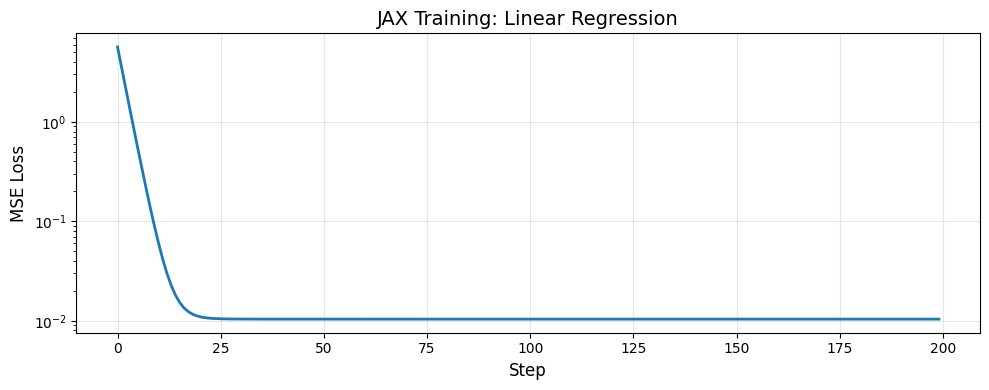

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, linewidth=2)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("MSE Loss", fontsize=12)
ax.set_title("JAX Training: Linear Regression", fontsize=14)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Comparison: PyTorch vs JAX

The same linear regression in both frameworks:

```python
# ===== PyTorch =====                    # ===== JAX =====
import torch                              import jax
                                          import jax.numpy as jnp

# Model                                  # Model
w = torch.randn(3, requires_grad=True)   params = {'w': jnp.zeros(3)}

# Forward + Loss                         # Forward + Loss
pred = x @ w                             def loss_fn(params, x, y):
loss = ((pred - y) ** 2).mean()              pred = x @ params['w']
                                              return jnp.mean((pred - y) ** 2)

# Backward                               # Grad
loss.backward()                          grads = jax.grad(loss_fn)(params, x, y)

# Update                                 # Update
with torch.no_grad():                    params = jax.tree.map(
    w -= lr * w.grad                         lambda p, g: p - lr * g,
    w.grad.zero_()                           params, grads)
```

| Aspect | PyTorch | JAX |
|---|---|---|
| State management | Mutable tensors with `.grad` | Immutable params passed explicitly |
| Gradient computation | `.backward()` mutates `.grad` | `jax.grad()` returns a new function |
| Parameter update | In-place subtraction | `tree.map` returns new params |
| Compilation | `torch.compile` (opt-in) | `jax.jit` (default pattern) |
| Debugging | Easy (print anywhere) | Harder (can't print inside jit) |

## What to Notice

1. **Functions, not objects.** JAX has no `nn.Module`, no `.parameters()`, no `.backward()`. Everything is a function that takes params and returns results.

2. **Transforms compose.** `jax.jit(jax.vmap(jax.grad(fn)))` is valid and powerful — compile a batched gradient computation in one line.

3. **`vmap` has no PyTorch equivalent.** Per-example gradients, Jacobians, and batched operations over arbitrary functions are trivial in JAX.

4. **Immutability enables everything.** JAX arrays can't be modified in place. This feels restrictive at first, but it's what makes `jit`, `grad`, and `vmap` possible.

5. **Explicit randomness is annoying but correct.** Passing keys everywhere is verbose, but it means random computations are reproducible and parallelizable — essential for distributed training.

6. **`jax.jit` is like XLA-level Triton.** Our Triton kernels fuse individual ops (softmax, layernorm). `jax.jit` fuses entire computation graphs via the XLA compiler — higher level, less control, but automatic.

## Resources

- [JAX Quickstart](https://jax.readthedocs.io/en/latest/quickstart.html) — Official tutorial
- [Thinking in JAX](https://jax.readthedocs.io/en/latest/thinking-in-jax.html) — Mental model guide
- [JAX 101](https://jax.readthedocs.io/en/latest/jax-101/index.html) — Comprehensive tutorial series
- [Flax](https://flax.readthedocs.io/) — Neural network library built on JAX (like PyTorch's nn)
- [Equinox](https://docs.kidger.site/equinox/) — PyTorch-like API on JAX (class-based models)